# TLCS — Improvements Showcase Notebook

This notebook documents every improvement made to the Traffic Light Control System (TLCS),
runs a training session, and produces visualisations that make the improvements tangible.

**Run cells top-to-bottom in order.**

---

## Improvements covered

| # | Phase | Area | Change |
|---|-------|------|--------|
| 1 | Update 1 | Algorithm | Frozen target network — stable Q-learning bootstraps |
| 2 | Update 1 | Algorithm | Huber Loss — robust to large early TD-errors |
| 3 | Update 1 | Tooling | Greedy evaluation script (test.py) |
| 4 | Update 1 | Reliability | Periodic checkpoint saving |
| 5 | Update 1 | Code quality | Edge IDs derived from shared constant |
| 6 | Update 1 | Code quality | Agent settings typed as `TrainingSettings` |
| 7 | Update 1 | Configuration | YAML + Pydantic models extended |
| 8 | Update 2 | Algorithm | 3-channel state: presence + speed + wait time |
| 9 | Update 2 | Code quality | State size derived from `NUM_CELLS` constant |
| 10 | Update 3 | Feature | Multi-agent NxN intersection grid |


## 1. Environment Setup

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC = PROJECT_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# SUMO needs to be launched from the project root so relative paths resolve.
os.chdir(PROJECT_ROOT)

print(f"Project root : {PROJECT_ROOT}")
print(f"src on path  : {SRC}")
print(f"cwd          : {Path.cwd()}")

Project root : C:\Users\Admin\Desktop\rel301m\refactor
src on path  : C:\Users\Admin\Desktop\rel301m\refactor\src
cwd          : C:\Users\Admin\Desktop\rel301m\refactor


## 2. GPU Check

In [2]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1024 ** 3
    print(f"GPU           : {gpu_name}")
    print(f"VRAM          : {vram:.1f} GB")
    print(f"CUDA version  : {torch.version.cuda}")
else:
    device = torch.device("cpu")
    print("No GPU found — training will run on CPU")

print(f"PyTorch       : {torch.__version__}")
print(f"Device in use : {device}")

GPU           : NVIDIA GeForce RTX 5060
VRAM          : 8.0 GB
CUDA version  : 12.8
PyTorch       : 2.12.0.dev20260314+cu128
Device in use : cuda


## 3. Settings

In [3]:
from constants import DEFAULT_MODEL_PATH, DEFAULT_SETTINGS_PATH, TRAINING_SETTINGS_FILE
from settings import load_training_settings

SETTINGS_FILE = PROJECT_ROOT / DEFAULT_SETTINGS_PATH / TRAINING_SETTINGS_FILE
OUT_PATH = PROJECT_ROOT / DEFAULT_MODEL_PATH

settings = load_training_settings(SETTINGS_FILE)

print(f"Settings file          : {SETTINGS_FILE}")
print(f"Output path            : {OUT_PATH}")
print()
print(f"Episodes               : {settings.total_episodes}")
print(f"Steps / episode        : {settings.max_steps}")
print(f"Cars / episode         : {settings.n_cars_generated}")
print(f"Batch size             : {settings.batch_size}")
print(f"Learning rate          : {settings.learning_rate}")
print(f"Gamma                  : {settings.gamma}")
print(f"Target update interval : {settings.target_update_interval}  replay steps")
print(f"Checkpoint interval    : {settings.checkpoint_interval}  episodes (0 = disabled)")

Settings file          : C:\Users\Admin\Desktop\rel301m\refactor\settings\training_settings.yaml
Output path            : C:\Users\Admin\Desktop\rel301m\refactor\model

Episodes               : 10
Steps / episode        : 5400
Cars / episode         : 1000
Batch size             : 100
Learning rate          : 0.001
Gamma                  : 0.75
Target update interval : 100  replay steps
Checkpoint interval    : 0  episodes (0 = disabled)


---

## 4. Improvement Deep-Dive (before training)

The next sections visualise the architectural improvements so you can see them
independently of a live SUMO run.

### 4.1 Improvement 1 — Target Network

**Problem:** The original agent computed Q-learning targets using the same network it was actively
updating. Targets shifted every gradient step, creating a moving-target feedback loop.

**Fix:** A second *frozen* copy of the network (the target network) is used to compute bootstrap
targets. Its weights are refreshed from the online network only every `target_update_interval`
replay steps.

```
Online network  ──trains──►  updated every step
Target network  ──frozen──►  copied from online every N steps
                             └─► used to compute:  r + γ · max Q_target(s', a')
```

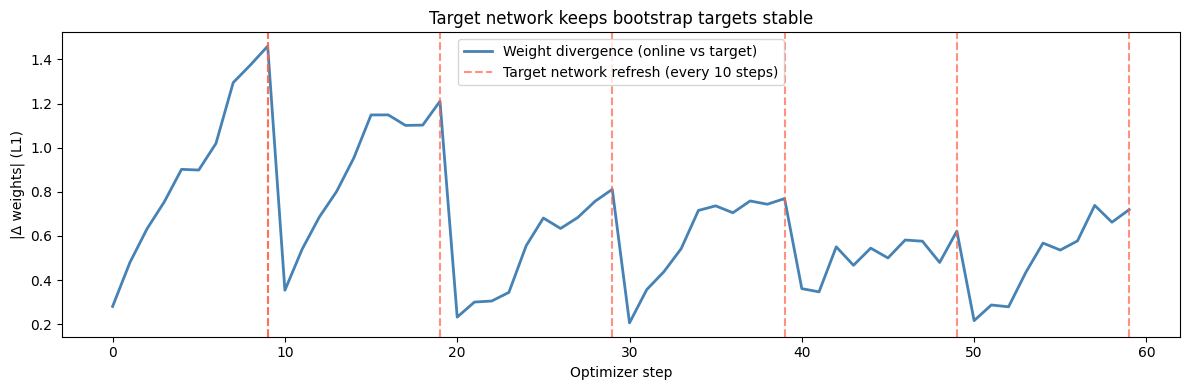

Red dashed lines = target network synced to online; divergence resets to 0 each time.


In [4]:
import copy

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from torch import nn

# Demonstrate that target model starts as an exact copy and diverges during training.
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(4, 4)
    def forward(self, x):
        return self.fc(x)

online = TinyNet()
target = copy.deepcopy(online)

# Simulate online updates accumulating divergence from the target.
optimizer = torch.optim.SGD(online.parameters(), lr=0.1)
x = torch.randn(8, 4)

steps, divergence = [], []
target_updates = []
TARGET_INTERVAL = 10

for step in range(60):
    # Online update.
    optimizer.zero_grad()
    loss = ((online(x) - torch.randn(8, 4)) ** 2).mean()
    loss.backward()
    optimizer.step()

    # Measure weight divergence.
    with torch.no_grad():
        diff = sum(
            (p_on - p_tgt).abs().sum().item()
            for p_on, p_tgt in zip(online.parameters(), target.parameters())
        )
    steps.append(step)
    divergence.append(diff)

    # Periodic target refresh.
    if (step + 1) % TARGET_INTERVAL == 0:
        target.load_state_dict(online.state_dict())
        target_updates.append(step)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, divergence, lw=2, color="steelblue", label="Weight divergence (online vs target)")
for upd in target_updates:
    ax.axvline(upd, color="tomato", linestyle="--", alpha=0.7)
ax.axvline(target_updates[0], color="tomato", linestyle="--", alpha=0.7,
           label=f"Target network refresh (every {TARGET_INTERVAL} steps)")
ax.set_xlabel("Optimizer step")
ax.set_ylabel("|Δ weights| (L1)")
ax.set_title("Target network keeps bootstrap targets stable")
ax.legend()
plt.tight_layout()
plt.show()
print("Red dashed lines = target network synced to online; divergence resets to 0 each time.")

### 4.2 Improvement 2 — Huber Loss vs MSE

**Problem:** MSE penalises large errors quadratically. A single badly-estimated Q-value early
in training can dominate the gradient and destabilise learning.

**Fix:** Huber Loss behaves like MSE for small errors and like MAE for large errors,
capping the gradient magnitude for outlier TD-errors.

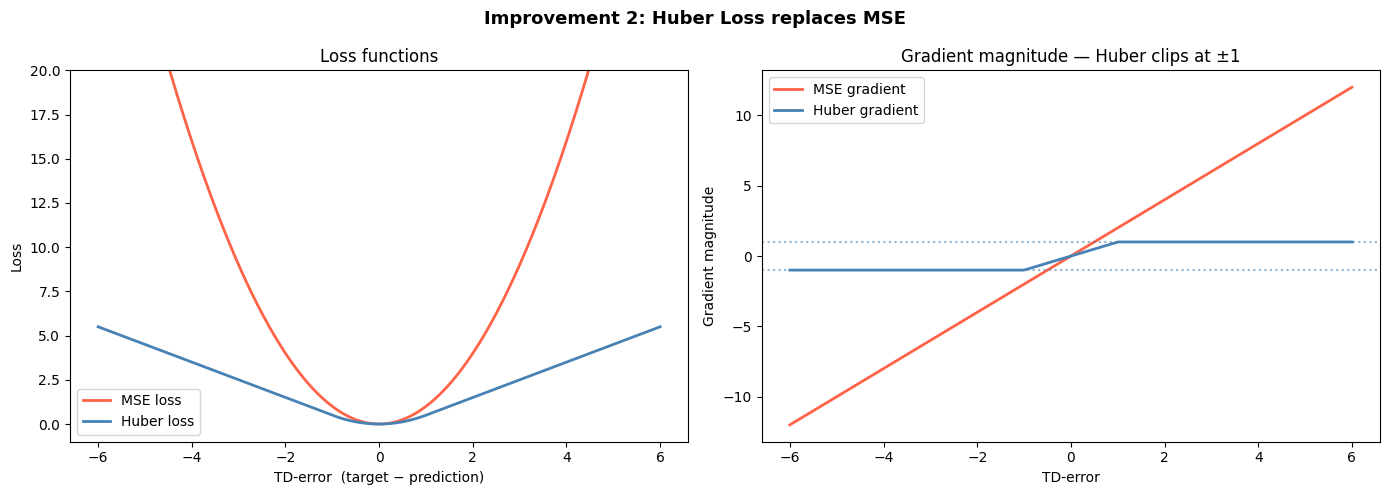

In [5]:
errors = np.linspace(-6, 6, 400)

mse_loss    = errors ** 2
huber_loss  = np.where(np.abs(errors) <= 1,
                        0.5 * errors ** 2,
                        np.abs(errors) - 0.5)

mse_grad    = 2 * errors
huber_grad  = np.where(np.abs(errors) <= 1, errors, np.sign(errors))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(errors, mse_loss,   lw=2, label="MSE loss",   color="tomato")
ax1.plot(errors, huber_loss, lw=2, label="Huber loss", color="steelblue")
ax1.set_xlabel("TD-error  (target − prediction)")
ax1.set_ylabel("Loss")
ax1.set_title("Loss functions")
ax1.legend()
ax1.set_ylim(-1, 20)

ax2.plot(errors, mse_grad,   lw=2, label="MSE gradient",   color="tomato")
ax2.plot(errors, huber_grad, lw=2, label="Huber gradient", color="steelblue")
ax2.axhline( 1, color="steelblue", linestyle=":", alpha=0.6)
ax2.axhline(-1, color="steelblue", linestyle=":", alpha=0.6)
ax2.set_xlabel("TD-error")
ax2.set_ylabel("Gradient magnitude")
ax2.set_title("Gradient magnitude — Huber clips at ±1")
ax2.legend()

fig.suptitle("Improvement 2: Huber Loss replaces MSE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.3 Improvement 8 — Three-Channel State Representation

**Problem:** The original binary occupancy vector could not distinguish a vehicle moving at full
speed from one that had been stationary for several minutes — both appeared identical.

**Fix:** Each of the 80 cells now carries **three** normalised values:
- Channel 0 — *presence* (0 or 1)
- Channel 1 — *average speed* / MAX_SPEED
- Channel 2 — *average waiting time* / MAX_WAIT_TIME

State vector grows from 80 → **240** elements.

NUM_CELLS  = 80   (8 lane-groups × 10 distance cells)
STATE_SIZE = 240  (NUM_CELLS × 3 channels)
MAX_SPEED     = 25.0 m/s
MAX_WAIT_TIME = 400.0 s


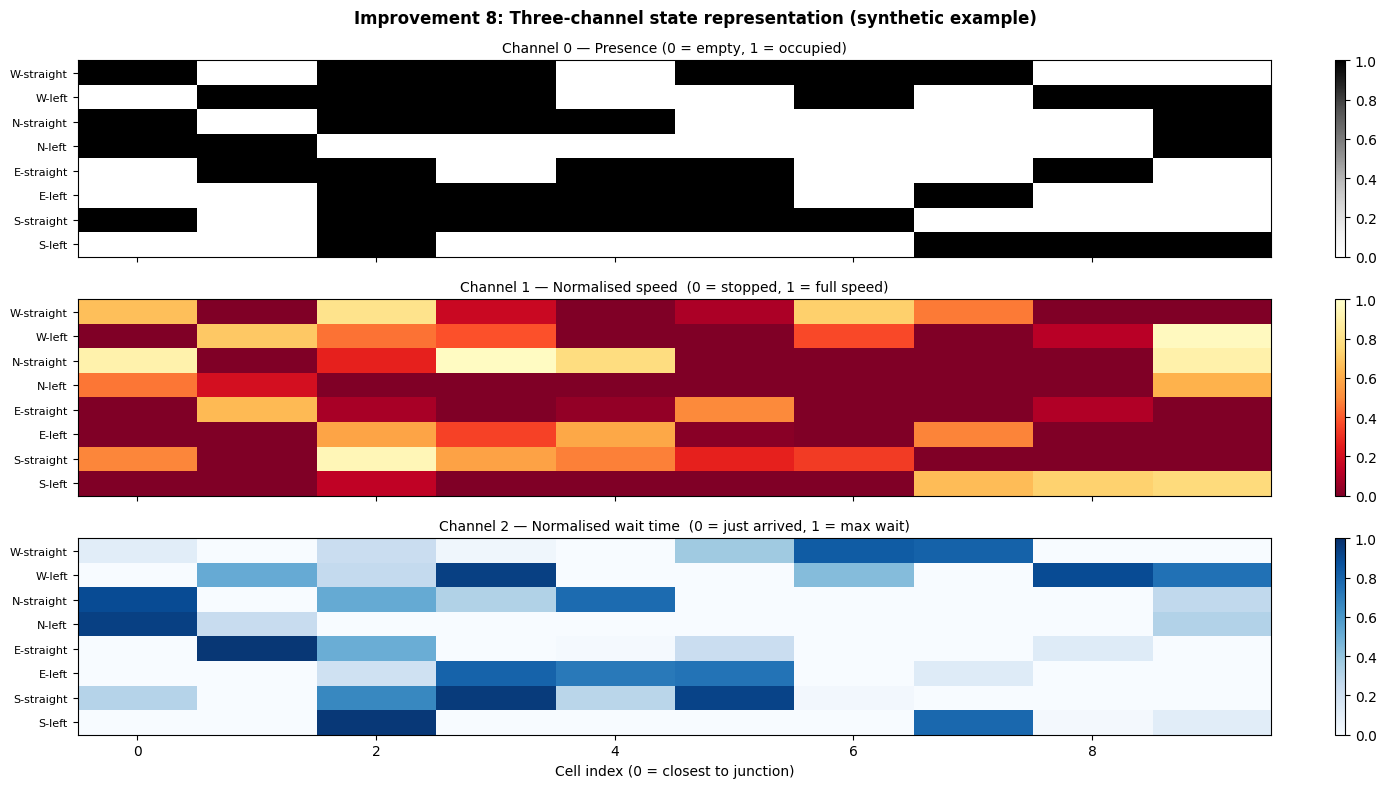

In [6]:
from constants import MAX_SPEED, MAX_WAIT_TIME, NUM_CELLS, STATE_SIZE

print(f"NUM_CELLS  = {NUM_CELLS}   (8 lane-groups × 10 distance cells)")
print(f"STATE_SIZE = {STATE_SIZE}  (NUM_CELLS × 3 channels)")
print(f"MAX_SPEED     = {MAX_SPEED} m/s")
print(f"MAX_WAIT_TIME = {MAX_WAIT_TIME} s")

# ------------------------------------------------------------------
# Synthetic example: two cells with same occupancy but different
# traffic conditions — invisible to the old binary state.
# ------------------------------------------------------------------
rng = np.random.default_rng(42)

# Simulate 8 lane-groups, each with 10 cells.
presence   = (rng.random((8, 10)) > 0.5).astype(float)
speed_norm = rng.uniform(0, 1, (8, 10)) * presence        # 0 if empty
wait_norm  = rng.uniform(0, 1, (8, 10)) * presence        # 0 if empty

lane_labels = ["W-straight", "W-left", "N-straight", "N-left",
               "E-straight", "E-left", "S-straight", "S-left"]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
cmaps = ["Greys", "YlOrRd_r", "Blues"]
titles = [
    "Channel 0 — Presence (0 = empty, 1 = occupied)",
    "Channel 1 — Normalised speed  (0 = stopped, 1 = full speed)",
    "Channel 2 — Normalised wait time  (0 = just arrived, 1 = max wait)",
]
data = [presence, speed_norm, wait_norm]

for ax, d, cmap, title in zip(axes, data, cmaps, titles):
    im = ax.imshow(d, cmap=cmap, aspect="auto", vmin=0, vmax=1)
    ax.set_yticks(range(8))
    ax.set_yticklabels(lane_labels, fontsize=8)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.02)

axes[-1].set_xlabel("Cell index (0 = closest to junction)")
fig.suptitle("Improvement 8: Three-channel state representation (synthetic example)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.4 Improvements 3 & 4 — Testing Script & Checkpoint Saving

**Improvement 3:** `src/test.py` loads a saved model and runs it with `epsilon=0`
(fully greedy). It reports per-episode and average cumulative wait / queue length.

**Improvement 4:** The training loop now saves checkpoint files at a configurable
interval (e.g. every 10 episodes), so a crash does not lose all progress.

In [ ]:
# Visualise what checkpoint files look like after training.
# This cell can be re-run after the training cell below.

checkpoints = sorted(OUT_PATH.glob("checkpoint_ep*.pt"))
model_file  = OUT_PATH / "trained_model.pt"

print("=== Saved artefacts in model/ ===")
for f in sorted(OUT_PATH.iterdir()) if OUT_PATH.exists() else []:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<35}  {size_kb:>7.1f} KB")

if not checkpoints:
    print("(No checkpoints yet — set checkpoint_interval > 0 in training_settings.yaml")
    print(" and re-run the training cell below.)")
else:
    print(f"\nFound {len(checkpoints)} checkpoint(s).")

### 4.5 Improvements 5 & 6 — Code Quality

**Improvement 5 — Single source of truth for edge IDs:**
The reward function now loops over `INCOMING_EDGES` instead of four hardcoded strings.

**Improvement 6 — Concrete type hint on Agent:**
Settings are now typed as `TrainingSettings`, not the bare `object` type.

In [7]:
import inspect

from constants import INCOMING_EDGES
from environment import reward as reward_mod
from agent.agent import Agent

# Show that INCOMING_EDGES is the single source of truth.
print("INCOMING_EDGES constant:", INCOMING_EDGES)
print()

# Show that get_queue_length iterates over that constant.
src = inspect.getsource(reward_mod.get_queue_length)
print("--- environment/reward.py: get_queue_length ---")
print(src)

# Show concrete type hint on Agent.__init__.
sig = inspect.signature(Agent.__init__)
print("--- Agent.__init__ signature ---")
for name, param in sig.parameters.items():
    if name == "self":
        continue
    ann = param.annotation
    ann_str = ann if isinstance(ann, str) else getattr(ann, "__name__", str(ann))
    default = "" if param.default is inspect.Parameter.empty else f" = {param.default!r}"
    print(f"  {name}: {ann_str}{default}")

INCOMING_EDGES constant: ('E2TL', 'N2TL', 'W2TL', 'S2TL')

--- environment/reward.py: get_queue_length ---
def get_queue_length() -> int:
    """Return the number of stopped vehicles on all incoming edges.

    Returns:
        Total number of vehicles with speed 0 on all four incoming edges.
    """
    return sum(traci.edge.getLastStepHaltingNumber(edge) for edge in INCOMING_EDGES)

--- Agent.__init__ signature ---
  settings: TrainingSettings
  epsilon: float = 1.0
  model_path: pathlib._local.Path | None = None
  model: Model | None = None
  input_dim: int | None = None


### 4.6 Improvement 7 — Configuration Extended

New YAML keys and their Pydantic validators:

In [8]:
from settings import TrainingSettings, TestingSettings

print("=== TrainingSettings fields ===")
for name, field in TrainingSettings.model_fields.items():
    annotation = field.annotation
    ann_str = getattr(annotation, "__name__", str(annotation))
    print(f"  {name:<30} : {ann_str}")

print()
print("=== TestingSettings fields ===")
for name, field in TestingSettings.model_fields.items():
    annotation = field.annotation
    ann_str = getattr(annotation, "__name__", str(annotation))
    print(f"  {name:<30} : {ann_str}")

=== TrainingSettings fields ===
  gui                            : bool
  total_episodes                 : int
  max_steps                      : int
  n_cars_generated               : int
  green_duration                 : int
  yellow_duration                : int
  turn_chance                    : float
  num_layers                     : int
  width_layers                   : int
  batch_size                     : int
  learning_rate                  : float
  training_epochs                : int
  memory_size_min                : int
  memory_size_max                : int
  gamma                          : float
  target_update_interval         : int
  checkpoint_interval            : int
  sumocfg_file                   : Path

=== TestingSettings fields ===
  gui                            : bool
  total_episodes                 : int
  max_steps                      : int
  n_cars_generated               : int
  episode_seed                   : int
  yellow_duration             

### 4.7 Improvement 10 — Multi-Agent Grid Architecture

The `src/grid/` package adds a scalable NxN multi-intersection path.
Three operating modes are supported:

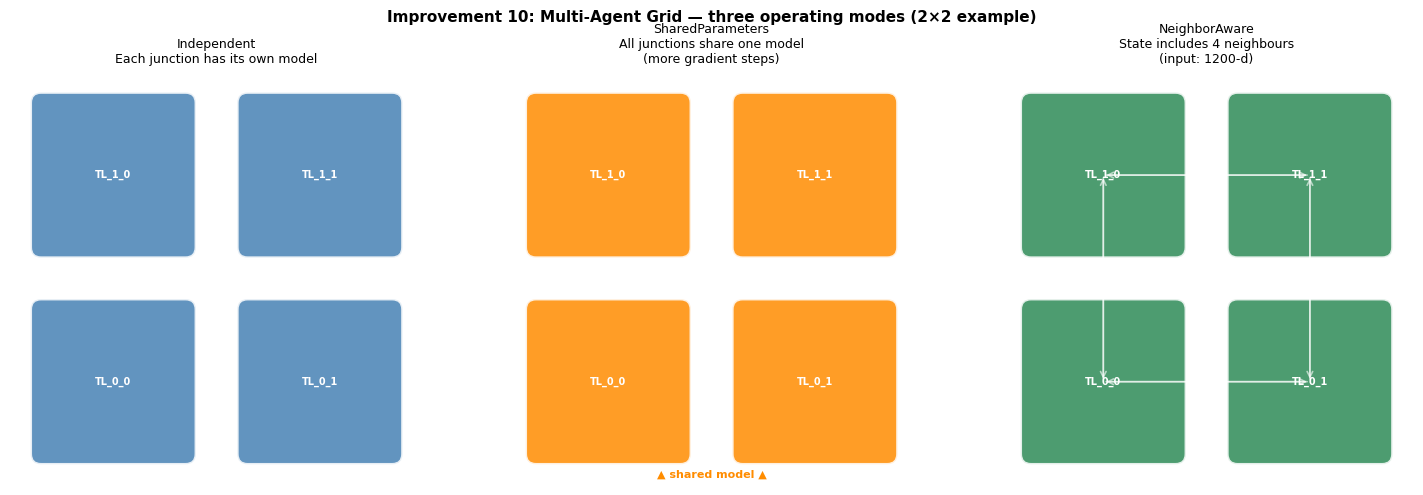

In [9]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

modes = [
    ("Independent",       "Each junction has its own model",          "steelblue"),
    ("SharedParameters",  "All junctions share one model\n(more gradient steps)", "darkorange"),
    ("NeighborAware",     "State includes 4 neighbours\n(input: 1200-d)",         "seagreen"),
]

N = 2  # 2×2 grid for illustration
for ax, (mode, desc, color) in zip(axes, modes):
    ax.set_xlim(-0.5, N - 0.5)
    ax.set_ylim(-0.5, N - 0.5)
    ax.set_aspect("equal")
    ax.set_title(f"{mode}\n{desc}", fontsize=9)
    ax.axis("off")

    for r in range(N):
        for c in range(N):
            rect = mpatches.FancyBboxPatch(
                (c - 0.35, r - 0.35), 0.7, 0.7,
                boxstyle="round,pad=0.05",
                facecolor=color, edgecolor="white", linewidth=2, alpha=0.85,
            )
            ax.add_patch(rect)
            label = f"TL_{r}_{c}"
            ax.text(c, r, label, ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold")

    # Draw neighbour arrows for NeighborAware.
    if mode == "NeighborAware":
        for r in range(N):
            for c in range(N):
                for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < N and 0 <= nc < N:
                        ax.annotate("",
                            xy=(nc, nr), xytext=(c, r),
                            arrowprops=dict(arrowstyle="->", color="white",
                                           lw=1.2, alpha=0.6),
                        )

    # Draw shared-model indicator.
    if mode == "SharedParameters":
        ax.text(0.5, -0.45, "▲ shared model ▲", ha="center", va="center",
                fontsize=8, color=color, fontweight="bold",
                transform=ax.transData)

fig.suptitle("Improvement 10: Multi-Agent Grid — three operating modes (2×2 example)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---

## 5. Train

Runs the full training session. SUMO must be installed and `SUMO_HOME` must be set.
Progress is logged to stdout via the `rich` handler.

In [10]:
from train import training_session

training_session(settings_file=SETTINGS_FILE, out_path=OUT_PATH)

[15:42:37] INFO     Model device: cuda                                                                  ]8;id=567704;file://C:\Users\Admin\Desktop\rel301m\refactor\src\agent\model.py\model.py]8;;\:]8;id=938020;file://C:\Users\Admin\Desktop\rel301m\refactor\src\agent\model.py#89\89]8;;\

           INFO     Creating new model for the Agent                                                   ]8;id=244974;file://C:\Users\Admin\Desktop\rel301m\refactor\src\agent\model.py\model.py]8;;\:]8;id=192235;file://C:\Users\Admin\Desktop\rel301m\refactor\src\agent\model.py#103\103]8;;\

           INFO     Episode 1 of 10                                                                     ]8;id=46003;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=295368;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#79\79]8;;\

[15:42:42] INFO             Epsilon: 1.0                                                               ]8;id=243907;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=94719;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#113\113]8;;\

           INFO             Reward: -30301.0                                                           ]8;id=989009;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=590554;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#114\114]8;;\

...

           INFO             Cumulative wait: 18950                                                     ]8;id=515233;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=494777;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#115\115]8;;\

           INFO             Avg queue: 3.5                                                             ]8;id=956070;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=620616;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#116\116]8;;\

           INFO     Start time: 2026-03-17 15:42:37.600315                                             ]8;id=581269;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=665627;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#126\126]8;;\

           INFO     End time: 2026-03-17 15:43:39.142937                                               ]8;id=812986;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=537016;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#127\127]8;;\

           INFO     Session info saved at: C:\Users\Admin\Desktop\rel301m\refactor\model               ]8;id=161928;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py\train.py]8;;\:]8;id=86639;file://C:\Users\Admin\Desktop\rel301m\refactor\src\train.py#128\128]8;;\

---

## 6. Training Results

The three plots below are saved by `plots.py` after training.
Lower (less negative) cumulative reward and shorter queues indicate the agent
is making better decisions as training progresses.

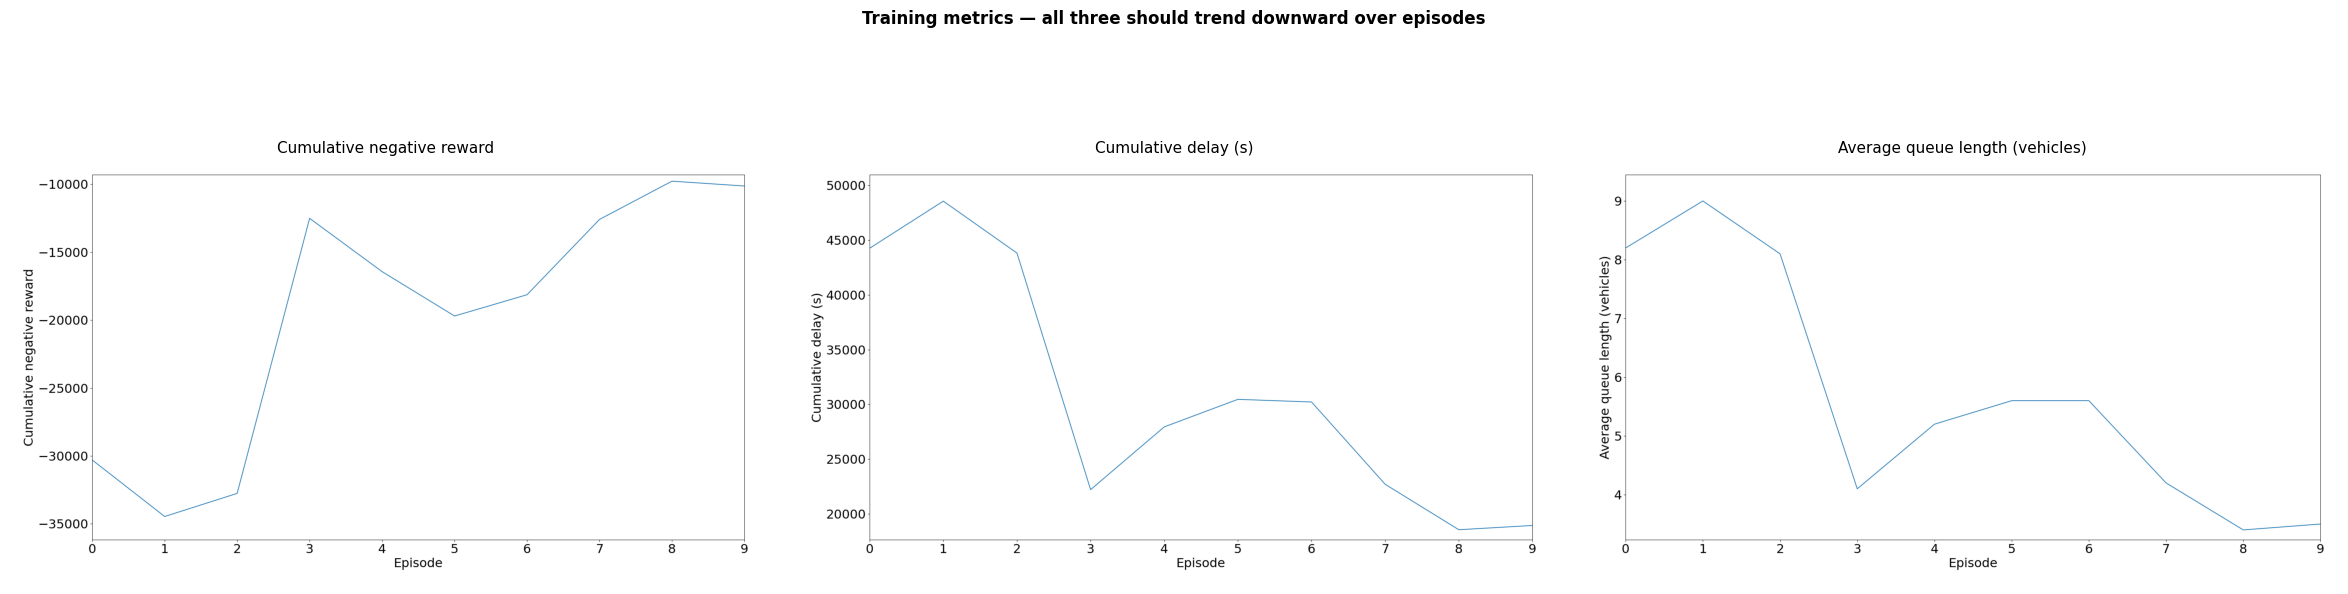

In [11]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

plots  = ["reward",                        "delay",                  "queue"]
titles = ["Cumulative negative reward",    "Cumulative delay (s)",   "Average queue length (vehicles)"]
ylabels = ["Sum of negative rewards",      "Total queue-steps (s)", "Vehicles queued (avg)"]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, name, title in zip(axes, plots, titles):
    img_path = OUT_PATH / f"plot_{name}.png"
    if img_path.exists():
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"{img_path.name}\nnot found\n(run training first)",
                ha="center", va="center", fontsize=10)
        ax.axis("off")

fig.suptitle("Training metrics — all three should trend downward over episodes",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.1 Interactive Plot from Raw Data

Re-reads the `plot_*_data.txt` files saved by `plots.py` and renders them with
matplotlib, adding a rolling average to make the trend clearer.

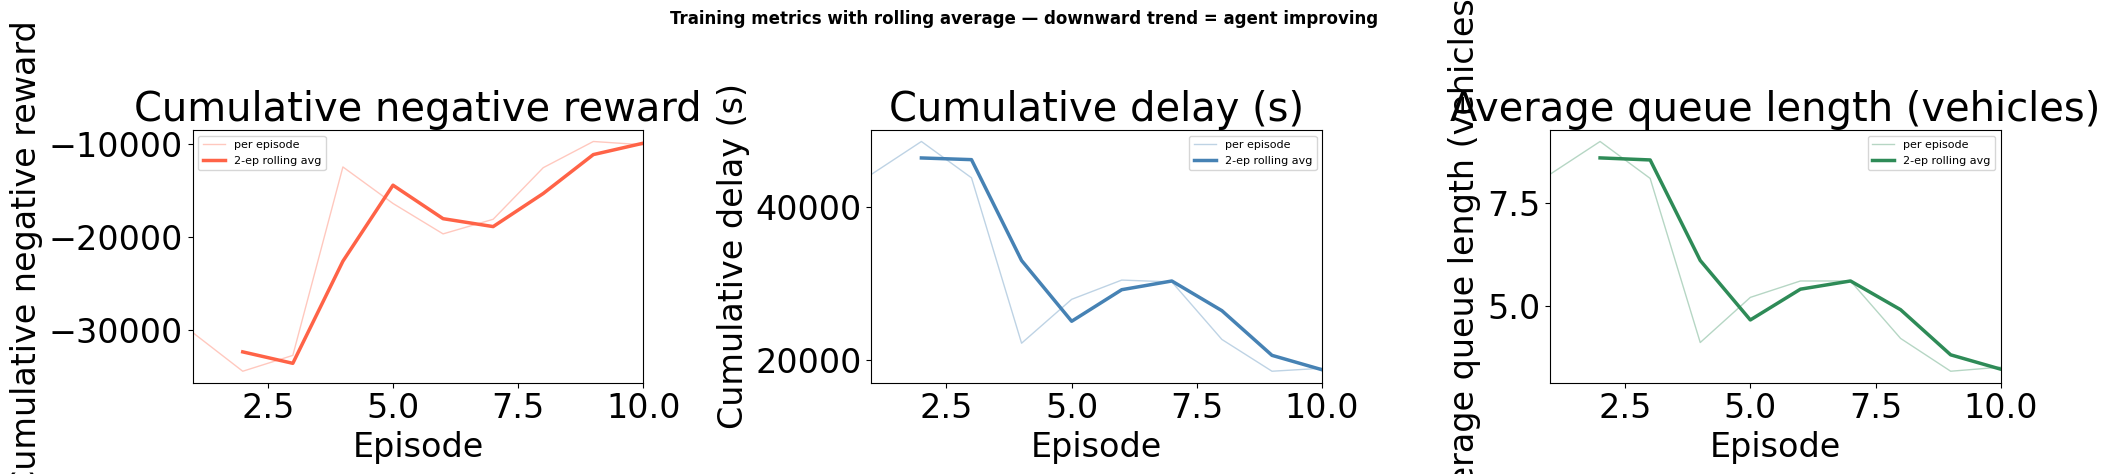

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plot_specs = [
    ("reward", "Cumulative negative reward",   "tomato"),
    ("delay",  "Cumulative delay (s)",          "steelblue"),
    ("queue",  "Average queue length (vehicles)", "seagreen"),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

for ax, (name, ylabel, color) in zip(axes, plot_specs):
    data_file = OUT_PATH / f"plot_{name}_data.txt"
    if not data_file.exists():
        ax.text(0.5, 0.5, f"No data yet\n({data_file.name})",
                ha="center", va="center")
        ax.axis("off")
        continue

    values = np.array([float(line) for line in data_file.read_text().splitlines() if line])
    episodes = np.arange(1, len(values) + 1)

    ax.plot(episodes, values, alpha=0.35, color=color, lw=1, label="per episode")

    # Rolling average.
    window = max(1, len(values) // 5)
    if len(values) >= window:
        roll = np.convolve(values, np.ones(window) / window, mode="valid")
        ax.plot(np.arange(window, len(values) + 1), roll,
                color=color, lw=2.5, label=f"{window}-ep rolling avg")

    ax.set_xlabel("Episode")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)
    ax.set_xlim(1, len(values))

fig.suptitle("Training metrics with rolling average — downward trend = agent improving",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.2 Epsilon Decay Visualisation

The agent uses a linear epsilon schedule: `ε = 1 − episode/total_episodes`.
This makes the policy shift from fully random exploration to near-greedy exploitation.

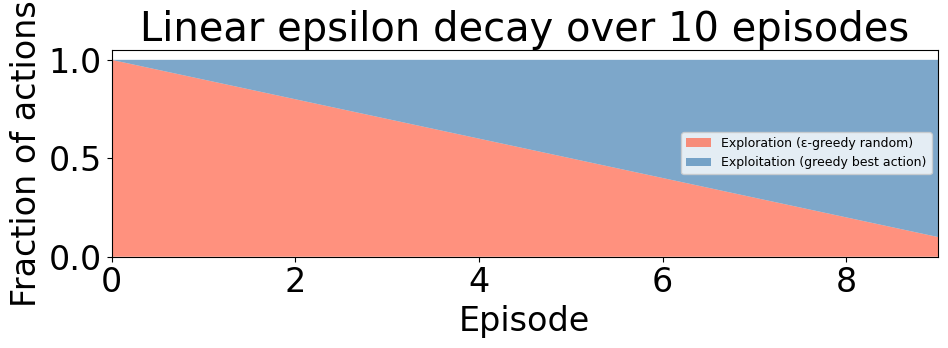

In [13]:
total_ep = settings.total_episodes
eps_values = [round(1.0 - ep / total_ep, 4) for ep in range(total_ep)]
explore_frac = [e for e in eps_values]
exploit_frac = [1 - e for e in eps_values]

fig, ax = plt.subplots(figsize=(10, 4))
ax.stackplot(
    range(total_ep),
    explore_frac,
    exploit_frac,
    labels=["Exploration (ε-greedy random)", "Exploitation (greedy best action)"],
    colors=["tomato", "steelblue"],
    alpha=0.7,
)
ax.set_xlabel("Episode")
ax.set_ylabel("Fraction of actions")
ax.set_title(f"Linear epsilon decay over {total_ep} episodes")
ax.legend(loc="center right", fontsize=9)
ax.set_xlim(0, total_ep - 1)
plt.tight_layout()
plt.show()

### 6.3 Checkpoint Timeline

Shows which checkpoints were saved and their file sizes, giving a quick overview
of how training progress is preserved.

In [15]:
import re

checkpoints = sorted(OUT_PATH.glob("checkpoint_ep*.pt")) if OUT_PATH.exists() else []

if not checkpoints:
    print("No checkpoints found. Set checkpoint_interval > 0 in training_settings.yaml.")
else:
    ep_nums   = [int(re.search(r"ep(\d+)", f.name).group(1)) for f in checkpoints]
    sizes_kb  = [f.stat().st_size / 1024 for f in checkpoints]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.barh(ep_nums, sizes_kb, height=max(1, settings.checkpoint_interval * 0.6),
            color="steelblue", alpha=0.8)
    ax.set_xlabel("File size (KB)")
    ax.set_ylabel("Episode")
    ax.set_title(f"Checkpoint timeline — {len(checkpoints)} checkpoint(s) saved")
    plt.tight_layout()
    plt.show()
    for ep, kb, f in zip(ep_nums, sizes_kb, checkpoints):
        print(f"  Episode {ep:>4}  →  {f.name}  ({kb:.1f} KB)")

No checkpoints found. Set checkpoint_interval > 0 in training_settings.yaml.


---

## 7. Evaluation (Improvement 3)

Run the trained model in greedy mode (ε=0) to get a reproducible performance score.
Requires SUMO and the trained model to be present.

In [16]:
from constants import DEFAULT_SETTINGS_PATH, TESTING_SETTINGS_FILE
from test import testing_session

TESTING_FILE = PROJECT_ROOT / DEFAULT_SETTINGS_PATH / TESTING_SETTINGS_FILE

if not (OUT_PATH / "trained_model.pt").exists():
    print("No trained model found at", OUT_PATH / "trained_model.pt")
    print("Run Section 5 (Train) first.")
else:
    testing_session(model_path=OUT_PATH, settings_file=TESTING_FILE)

[15:44:37] INFO     Model device: cuda                                                                  ]8;id=9015;file://C:\Users\Admin\Desktop\rel301m\refactor\src\agent\model.py\model.py]8;;\:]8;id=820423;file://C:\Users\Admin\Desktop\rel301m\refactor\src\agent\model.py#89\89]8;;\

           INFO     Loading trained model weights from                                                 ]8;id=979833;file://C:\Users\Admin\Desktop\rel301m\refactor\src\agent\model.py\model.py]8;;\:]8;id=229923;file://C:\Users\Admin\Desktop\rel301m\refactor\src\agent\model.py#100\100]8;;\
                    C:\Users\Admin\Desktop\rel301m\refactor\model\trained_model.pt                                 

           INFO     Test episode 1 of 5 (seed=10000)                                                     ]8;id=977362;file://C:\Users\Admin\Desktop\rel301m\refactor\src\test.py\test.py]8;;\:]8;id=752265;file://C:\Users\Admin\Desktop\rel301m\refactor\src\test.py#55\55]8;;\

FatalTraCIError: Connection closed by SUMO.

---

## 8. Summary

| # | Improvement | Where to see it in this notebook |
|---|-------------|-----------------------------------|
| 1 | Target network — stable bootstrap targets | §4.1 divergence plot |
| 2 | Huber Loss — robust to large TD-errors | §4.2 loss & gradient comparison |
| 3 | Greedy evaluation script | §7 testing session |
| 4 | Periodic checkpoint saving | §4.4 & §6.3 checkpoint timeline |
| 5 | Edge IDs from shared constant | §4.5 source inspection |
| 6 | Agent typed as `TrainingSettings` | §4.5 signature inspection |
| 7 | YAML + Pydantic config extended | §4.6 field listing |
| 8 | Three-channel state (240-d) | §4.3 heatmap |
| 9 | `STATE_SIZE` derived from `NUM_CELLS` | §4.3 constants printout |
| 10 | Multi-agent NxN grid | §4.7 architecture diagram |
